In [8]:
# Import data science packages
import pandas as pd
import numpy as np

# Import visualization and geoanalytics packages
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.geometry import box
import pyproj
pd.set_option('display.max_rows', 500)

In [3]:
df = gpd.read_file('sample_data.geojson')

In [10]:
df.head()

,ticket_number,issue_date,issue_time,rp_state_plate,plate_expiry_date,make,body_style,color,location,route,agency,violation_code,violation_description,fine_amount,agency_desc,color_desc,body_style_desc,meter_id,marked_time,geometry
0,4514737231,2020-07-01,12:43,CA,202012,TOYT,PA,SL,1717 WESTERN AVE,00131,51,22507.8A-,DISABLED PARKING/NO DP ID,363,51 - DOT - WESTERN,SILVER,PASSENGER CAR,None,None,POINT (1837993.121 6468052.624)
1,4515714932,2020-07-01,16:06,CA,202103,ACUR,PA,BK,600 WILSHIRE PL,00400,54,88.13B+,METER EXP.,63,54 - DOT - HOLLYWOOD,BLACK,PASSENGER CAR,VW478,None,POINT (1845002.310 6474486.821)
2,4515722595,2020-07-01,23:20,CA,202010,BMW,PA,BL,1426 HARRIDGE DR,203A,51,22502A,18 IN. CURB/2 WAY,63,51 - DOT - WESTERN,BLUE,PASSENGER CAR,None,None,POINT (1857684.566 6434742.246)
3,4515573952,2020-07-01,23:15,CA,202104,HYUN,PA,GY,5250 CENTURY BLVD,00204,51,22500.1+,PARKED IN FIRE LANE,63,51 - DOT - WESTERN,GREY,PASSENGER CAR,None,None,POINT (1802726.364 6449133.737)
4,4515896615,2020-07-01,23:14,PA,201707,SUBA,PA,GY,800 ARDMORE AVE S,402A,54,80.56E4+,RED ZONE,93,54 - DOT - HOLLYWOOD,GREY,PASSENGER CAR,None,None,POINT (1843515.536 6470199.041)


In [9]:
df.geometry[:100]

0     POINT (1837993.121 6468052.624)
1     POINT (1845002.310 6474486.821)
2     POINT (1857684.566 6434742.246)
3     POINT (1802726.364 6449133.737)
4     POINT (1843515.536 6470199.041)
5     POINT (1744647.836 6469884.534)
6     POINT (1896270.857 6427306.244)
7     POINT (1826911.906 6471938.004)
8     POINT (1802726.364 6449133.737)
9     POINT (1857684.566 6434742.246)
10    POINT (1849286.506 6472200.290)
11    POINT (1853753.961 6456096.693)
12    POINT (1891483.328 6399563.124)
13    POINT (1848976.772 6472200.257)
14    POINT (1820042.271 6472907.076)
15    POINT (1812209.484 6474236.764)
16    POINT (1807648.917 6481403.972)
17    POINT (1861627.862 6481559.191)
18    POINT (1861446.104 6474660.949)
19    POINT (1859151.175 6473587.907)
20    POINT (1809945.700 6473595.293)
21    POINT (1860279.275 6473338.303)
22    POINT (1860540.428 6473662.707)
23    POINT (1854076.138 6478256.485)
24    POINT (1858952.459 6473838.251)
25    POINT (1806173.481 6469606.964)
26    POINT 

In [11]:
dg = pd.read_csv('Original_data/Parking_Citations_After_July_1_2015.csv', usecols = 
                 ['Issue Date', 'Issue time', 'Location', 'Violation Description', 'Latitude', 'Longitude'])

In [12]:
dg.columns = ['Issue_Date', 'Issue_Time', 'Location', 'Violation_Description', 'Latitude', 'Longitude']

In [13]:
dg.head()

,Issue_Date,Issue_Time,Location,Violation_Description,Latitude,Longitude
0,2019/09/17 12:00:00 AM,817.0,1324 84TH PL W,NO PARK/STREET CLEAN,6.471017e+06,1.808559e+06
1,2019/09/17 12:00:00 AM,811.0,1000 85TH ST W,METER EXP.,6.473192e+06,1.808298e+06
2,2019/09/17 12:00:00 AM,809.0,1000 85TH ST W,NO PARK/STREET CLEAN,6.473192e+06,1.808298e+06
3,2019/09/17 12:00:00 AM,805.0,8021 VERMONT AVE,NO PARK/STREET CLEAN,6.473164e+06,1.810388e+06
4,2019/09/17 12:00:00 AM,727.0,1473 45TH ST W,BLOCKING DRIVEWAY,6.469917e+06,1.823537e+06


In [14]:
dg.isna().sum()

Issue_Date                  0
Issue_Time               2167
Location                  346
Violation_Description     890
Latitude                    2
Longitude                   2
dtype: int64

In [15]:
len(dg)

8706412

In [16]:
dg = dg.dropna()

In [17]:
dg.isna().sum()

Issue_Date               0
Issue_Time               0
Location                 0
Violation_Description    0
Latitude                 0
Longitude                0
dtype: int64

In [18]:
dg.describe()

,Issue_Time,Latitude,Longitude
count,8.703063e+06,8.703063e+06,8.703063e+06
mean,1.191127e+03,5.627485e+06,1.620858e+06
std,4.753352e+02,2.139752e+06,5.893104e+05
min,0.000000e+00,9.999900e+04,9.999900e+04
25%,9.050000e+02,6.423773e+06,1.826165e+06
50%,1.147000e+03,6.453452e+06,1.842364e+06
75%,1.457000e+03,6.475623e+06,1.858229e+06
max,2.359000e+03,6.514332e+06,1.942669e+06


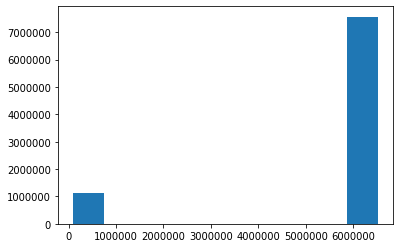

In [19]:
plt.hist(dg.Latitude)
plt.show()

In [20]:
dg[(dg['Latitude'] < 100000)|(dg['Longitude'] < 100000)]

,Issue_Date,Issue_Time,Location,Violation_Description,Latitude,Longitude
5,2019/09/17 12:00:00 AM,611.0,1507 FLORENCE AVE,PARKED ON SIDEWALK,99999.0,99999.0
51,2019/09/17 12:00:00 AM,739.0,593 WASHINGTON BLVD,NO PARK/STREET CLEAN,99999.0,99999.0
52,2019/09/17 12:00:00 AM,738.0,593 WASHINGTON BLVD,NO PARK/STREET CLEAN,99999.0,99999.0
68,2019/09/17 12:00:00 AM,537.0,945 FLOWER AVE,OVNIGHT PRK W/OUT PE,99999.0,99999.0
75,2019/09/17 12:00:00 AM,224.0,13050 MINDANAO WAY,NO PARKING,99999.0,99999.0
...,...,...,...,...,...,...
8706085,2015/07/02 12:00:00 AM,924.0,1500 BLK SHELL AVE,NO PARK/STREET CLEAN,99999.0,99999.0
8706122,2015/07/02 12:00:00 AM,1425.0,239 MAPLE AVE S,YELLOW ZONE,99999.0,99999.0
8706142,2015/07/02 12:00:00 AM,1609.0,12150 VICTORY BOULEVARD,NO STOPPING/ANTI-GRI,99999.0,99999.0
8706341,2015/07/02 12:00:00 AM,1215.0,2233 21ST ST W,NO PARK/STREET CLEAN,99999.0,99999.0


In [21]:
dg = dg[(dg['Latitude'] > 100000)|(dg['Longitude'] > 100000)]

In [22]:
dg = dg[dg['Violation_Description']  == 'NO PARK/STREET CLEAN']

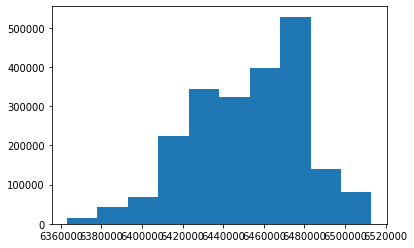

In [23]:
plt.hist(dg.Latitude)
plt.show()

In [24]:
def time_padding(time):
    time = str(int(time))
    return '0'*(4-len(time)) + time
# Apply padding to Issue_time
dg['Issue_Time'] = dg['Issue_Time'].apply(time_padding)
# Creating combined Datetime column
dg['Issue_Date'] = dg['Issue_Date'].apply(lambda x: x[:10])
dg['Datetime'] = pd.to_datetime(dg['Issue_Date'] + ' ' + dg['Issue_Time'], format='%Y/%m/%d %H%M')
# Filter for street cleaning violations

In [25]:
dg['Hour'] = dg['Datetime'].apply(lambda x: x.hour)

In [26]:
dg.head()

,Issue_Date,Issue_Time,Location,Violation_Description,Latitude,Longitude,Datetime,Hour
0,2019/09/17,0817,1324 84TH PL W,NO PARK/STREET CLEAN,6.471017e+06,1.808559e+06,2019-09-17 08:17:00,8
2,2019/09/17,0809,1000 85TH ST W,NO PARK/STREET CLEAN,6.473192e+06,1.808298e+06,2019-09-17 08:09:00,8
3,2019/09/17,0805,8021 VERMONT AVE,NO PARK/STREET CLEAN,6.473164e+06,1.810388e+06,2019-09-17 08:05:00,8
16,2019/09/17,1228,1300 RIVIERA AVE,NO PARK/STREET CLEAN,6.419071e+06,1.819233e+06,2019-09-17 12:28:00,12
17,2019/09/17,1226,1203 RIVIERA AVE,NO PARK/STREET CLEAN,6.418885e+06,1.819472e+06,2019-09-17 12:26:00,12


In [27]:
dg[['Latitude', 'Longitude']]

,Latitude,Longitude
0,6.471017e+06,1.808559e+06
2,6.473192e+06,1.808298e+06
3,6.473164e+06,1.810388e+06
16,6.419071e+06,1.819233e+06
17,6.418885e+06,1.819472e+06
...,...,...
8706365,6.464338e+06,1.838655e+06
8706366,6.463978e+06,1.838879e+06
8706367,6.463978e+06,1.839074e+06
8706368,6.420361e+06,1.819769e+06


In [28]:
# Conversion using pyproj module
inProj = pyproj.Proj({'init': 'epsg:2229'}, preserve_units=True) # make sure unit preserve 
outProj = pyproj.Proj({'init': 'epsg:4326'})
y_1,x_1 = pyproj.transform(inProj,outProj,dg["Latitude"].values, dg["Longitude"].values)

In [29]:
# Add on the converted coordinates
dg["Latitude"] = x_1
dg["Longitude"] = y_1
dg.head()

,Issue_Date,Issue_Time,Location,Violation_Description,Latitude,Longitude,Datetime,Hour
0,2019/09/17,0817,1324 84TH PL W,NO PARK/STREET CLEAN,33.961646,-118.298938,2019-09-17 08:17:00,8
2,2019/09/17,0809,1000 85TH ST W,NO PARK/STREET CLEAN,33.960946,-118.291763,2019-09-17 08:09:00,8
3,2019/09/17,0805,8021 VERMONT AVE,NO PARK/STREET CLEAN,33.966689,-118.291875,2019-09-17 08:05:00,8
16,2019/09/17,1228,1300 RIVIERA AVE,NO PARK/STREET CLEAN,33.990430,-118.470404,2019-09-17 12:28:00,12
17,2019/09/17,1226,1203 RIVIERA AVE,NO PARK/STREET CLEAN,33.991083,-118.471020,2019-09-17 12:26:00,12


In [30]:
dg[['Latitude', 'Longitude']]

,Latitude,Longitude
0,33.961646,-118.298938
2,33.960946,-118.291763
3,33.966689,-118.291875
16,33.990430,-118.470404
17,33.991083,-118.471020
...,...,...
8706365,34.044289,-118.321281
8706366,34.044900,-118.322472
8706367,34.045437,-118.322474
8706368,33.991918,-118.466156


In [31]:
dg.to_file("lucky_parking.geojson", driver='GeoJSON')

AttributeError: 'DataFrame' object has no attribute 'to_file'

In [39]:
# Read file into dataframe
df = pd.read_csv('Coordinates Converted_Simplified Citation After 2015 July to 2019.csv')
# Turn Lat,Lon into tuple
df['Coordinates'] = (list(zip(df.Latitude, df.Longitude)))
# Remove index
del df['Unnamed: 0']
# Rename columns
df.columns =  ['Issue_Date', 'Issue_time', 'Location', 'Violation_Description', 'Day_of_Week',
       'Latitude', 'Longitude', 'Coordinates']
# Time padding function
def time_padding(time):
    time = str(int(time))
    return '0'*(4-len(time)) + time
# Apply padding to Issue_time
df['Issue_time'] = df['Issue_time'].apply(time_padding)
# Creating combined Datetime column
df['Datetime'] = pd.to_datetime(df['Issue_Date'] + ' ' + df['Issue_time'], format='%Y-%m-%d %H%M')
# Filter for street cleaning violations
df = df[df['Violation_Description'] == 'NO PARK/STREET CLEAN']

In [40]:
# Turn citation coordinates into Geopandas geometry column
geometry = [Point(xy) for xy in zip(df.Longitude, df.Latitude)]
crs = {'init': 'epsg:4326'}
geo_df = gpd.GeoDataFrame(df, crs=crs, geometry=geometry)

In [45]:
geo_df.columns

Index(['Issue_Date', 'Issue_time', 'Location', 'Violation_Description',
       'Day_of_Week', 'Latitude', 'Longitude', 'Datetime', 'geometry'],
      dtype='object')

In [35]:
# Created citation hour columns to compare visualization
geo_df['Hour'] = geo_df.Datetime.apply(lambda x: x.hour)

In [46]:
geo_df.to_file("lucky_parking.geojson", driver='GeoJSON')

In [47]:
geo_df.head()

,Issue_Date,Issue_time,Location,Violation_Description,Day_of_Week,Latitude,Longitude,Datetime,geometry
0,2019-09-17,1205,309 WINDWARD AVE,NO PARK/STREET CLEAN,Tuesday,33.989412,-118.469024,2019-09-17 12:05:00,POINT (-118.46902 33.98941)
1,2019-09-17,0853,934 84TH ST W,NO PARK/STREET CLEAN,Tuesday,33.962435,-118.290126,2019-09-17 08:53:00,POINT (-118.29013 33.96244)
2,2019-09-17,0833,2601 MONMOUTH AVE,NO PARK/STREET CLEAN,Tuesday,34.032120,-118.284957,2019-09-17 08:33:00,POINT (-118.28496 34.03212)
3,2019-09-17,1015,615 HAMPTON DR,NO PARK/STREET CLEAN,Tuesday,33.994284,-118.474775,2019-09-17 10:15:00,POINT (-118.47477 33.99428)
4,2019-09-17,1007,1346 MCCADDEN PL N,NO PARK/STREET CLEAN,Tuesday,34.095217,-118.337472,2019-09-17 10:07:00,POINT (-118.33747 34.09522)


In [44]:
del geo_df['Coordinates']

In [22]:
# Import steet centerline geometry with Geopandas
st_df = gpd.read_file('Streets_Centerline/Streets_Centerline.shp')

In [23]:
# Function to plot points
def plot_points(latitude, longitude, zoom=0.06, column='Day_of_Week', fsize=20, markersize=10):
    area_of_interest = (latitude, longitude)
    diameter_oi = zoom
    bbox = box(area_of_interest[1]-diameter_oi, area_of_interest[0]-diameter_oi,area_of_interest[1]
            +diameter_oi, area_of_interest[0]+diameter_oi)
    f, ax = plt.subplots(1, figsize=(fsize,fsize))
    ax.set_aspect('equal')
    st_df[st_df.geometry.within(bbox)].plot(ax=ax, color='grey', zorder=1)
    geo_df[geo_df.geometry.within(bbox)].plot(ax=ax, column = column, legend=True, zorder=2, markersize=markersize)
    return plt.show()

In [24]:
# Function to plot streets
def plot_streets(latitude, longitude, zoom=0.06, column='Day_of_Week', fsize=20, buffer=0.001, linewidth=2):
    area_of_interest = (latitude, longitude)
    diameter_oi = zoom
    bbox = box(area_of_interest[1]-diameter_oi, area_of_interest[0]-diameter_oi,area_of_interest[1]
            +diameter_oi, area_of_interest[0]+diameter_oi)
    fil_st_df = st_df[st_df.geometry.within(bbox)]
    fil_cit = geo_df[geo_df.geometry.within(bbox)].copy()
    fil_cit['geometry'] = fil_cit['geometry'].buffer(buffer)
    sjoined = gpd.sjoin(fil_st_df, fil_cit, how='inner', op='intersects')
    # st_df = gpd.read_file('Streets_Centerline/Streets_Centerline.shp', bbox=bbox )
    f, ax = plt.subplots(1, figsize=(fsize,fsize))
    ax.set_aspect('equal')
    fil_st_df.plot(ax=ax, color='grey', zorder=1)
    sjoined.plot(ax=ax, column = column, legend=True, zorder=2, linewidth=linewidth)
    return plt.show()

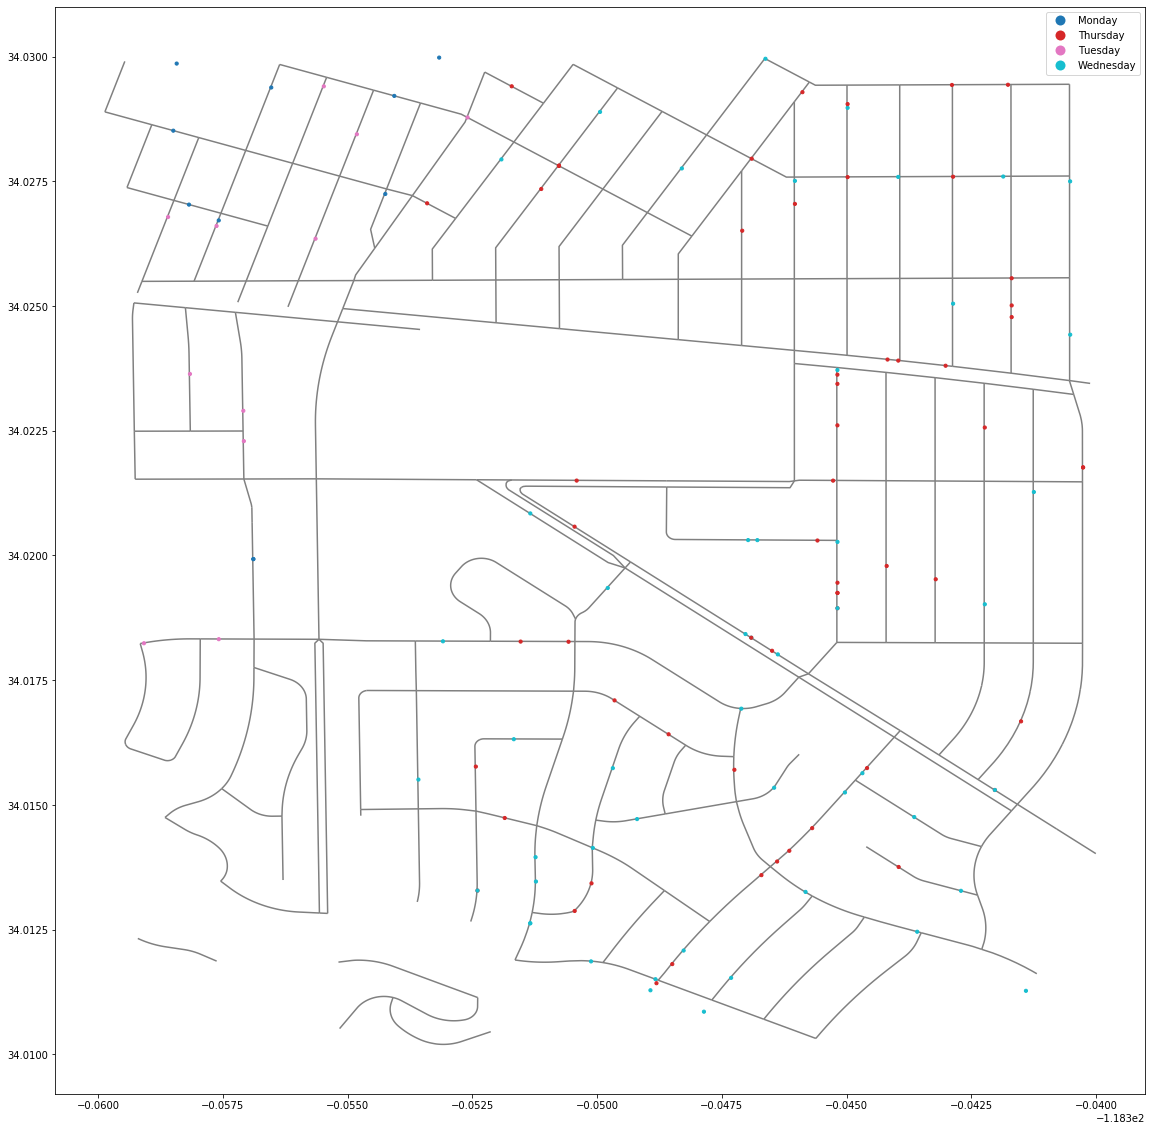

In [33]:
plot_points(34.02, -118.350, zoom=0.01)

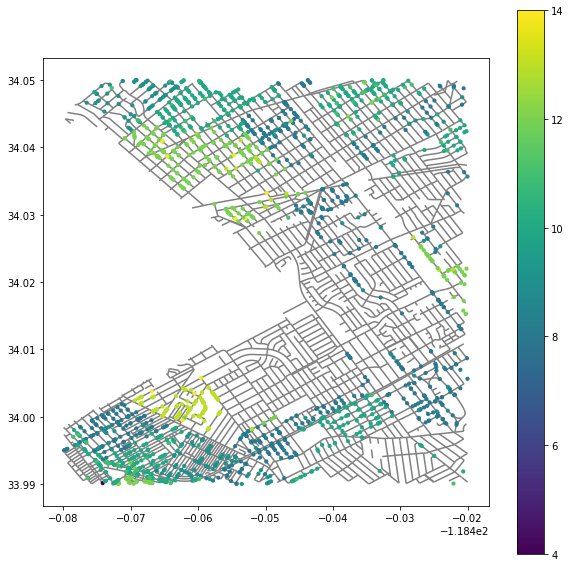

In [63]:
plot_points(34.02, -118.450, column='Hour', zoom=0.03, fsize=10)

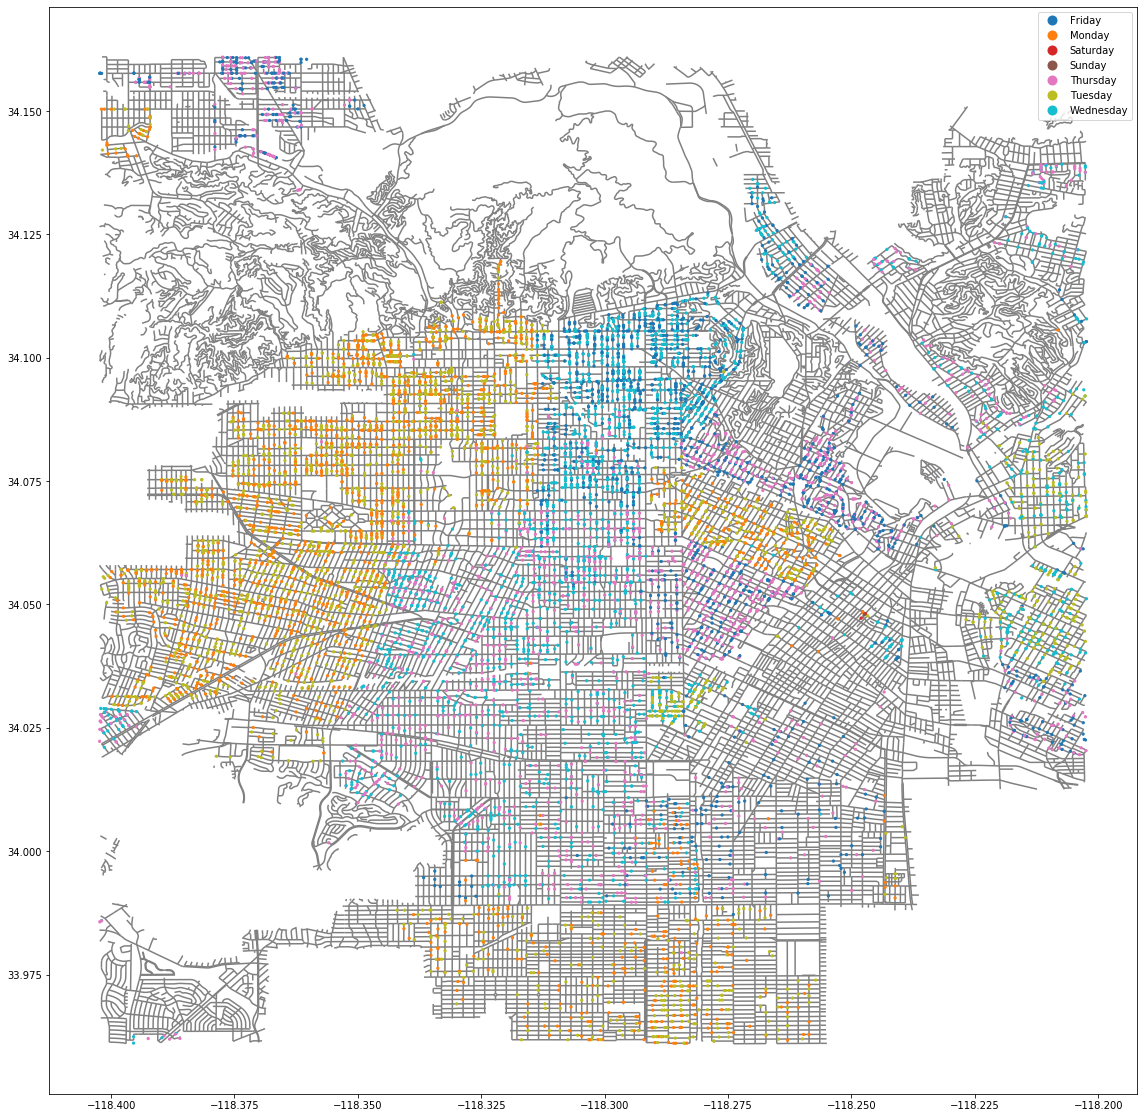

In [13]:
plot_points(34.060988, -118.302358, zoom=0.1, markersize=5)

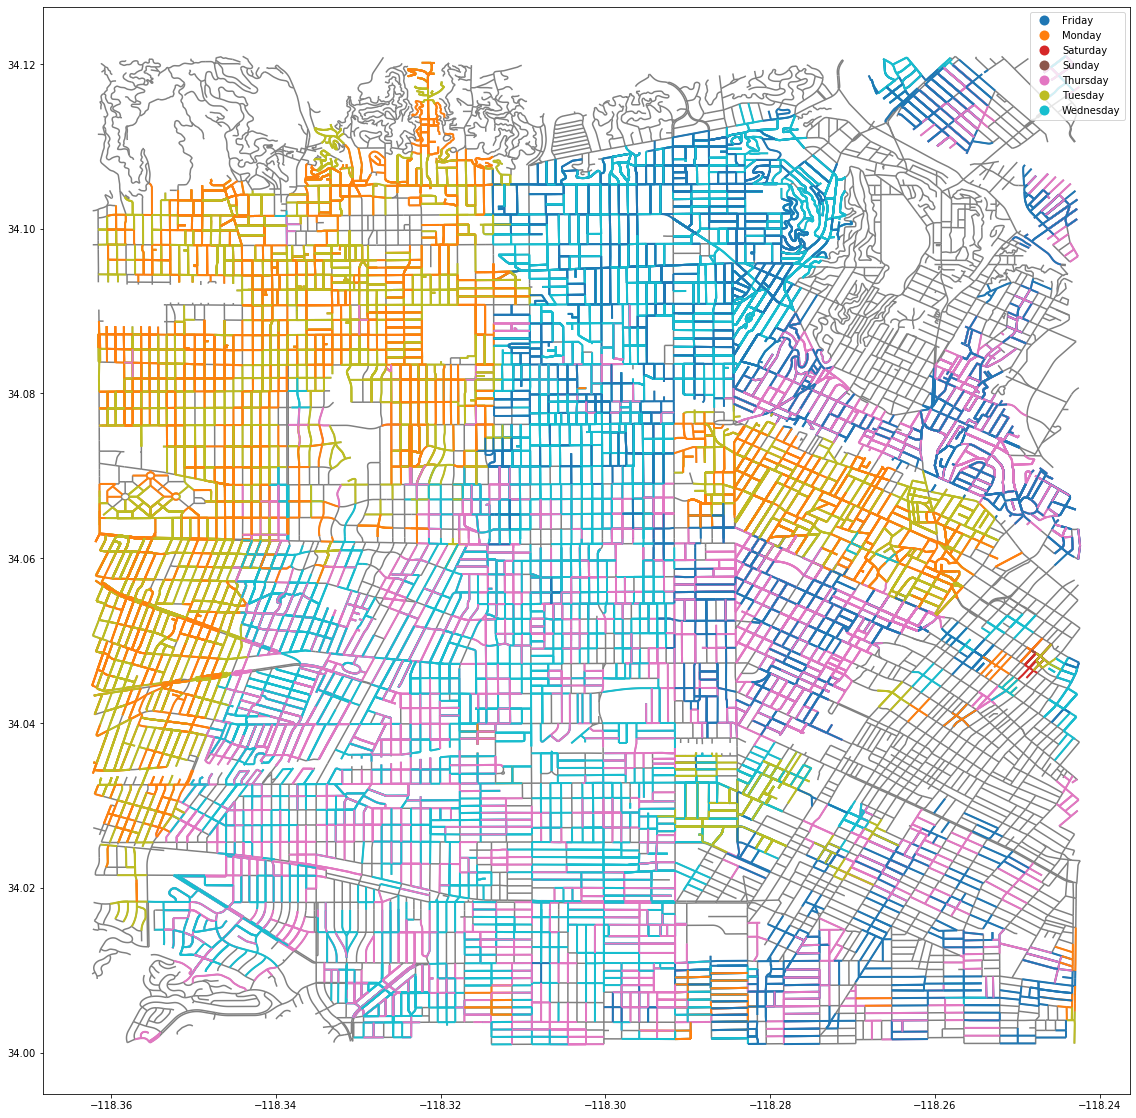

In [34]:
plot_streets(34.060988, -118.302358)

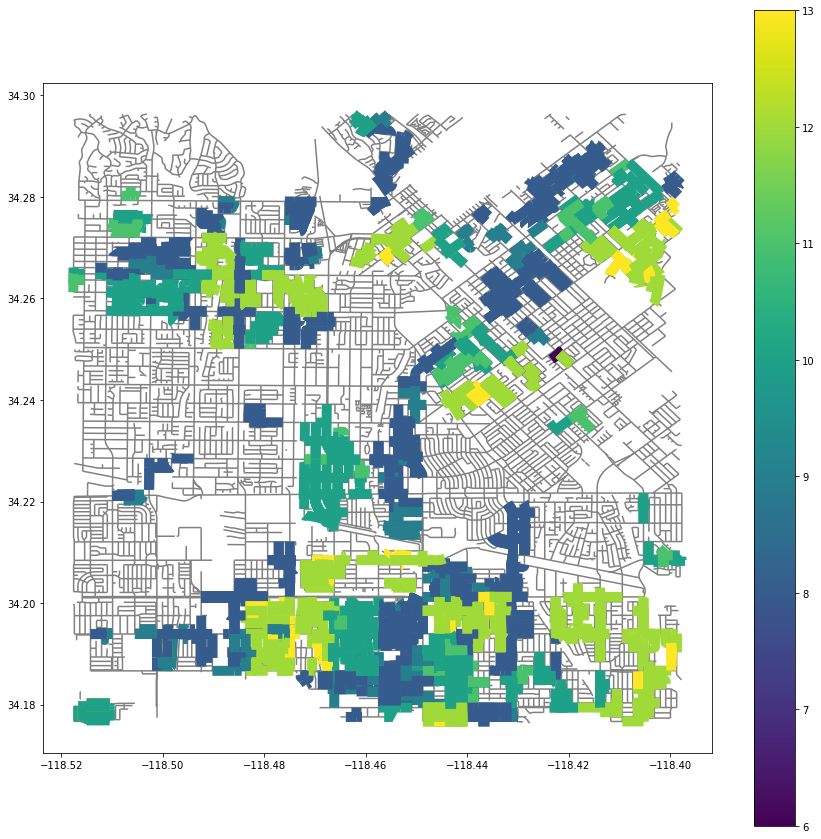

In [25]:
plot_streets(34.2364, -118.4577, fsize=15, column='Hour', linewidth=10)

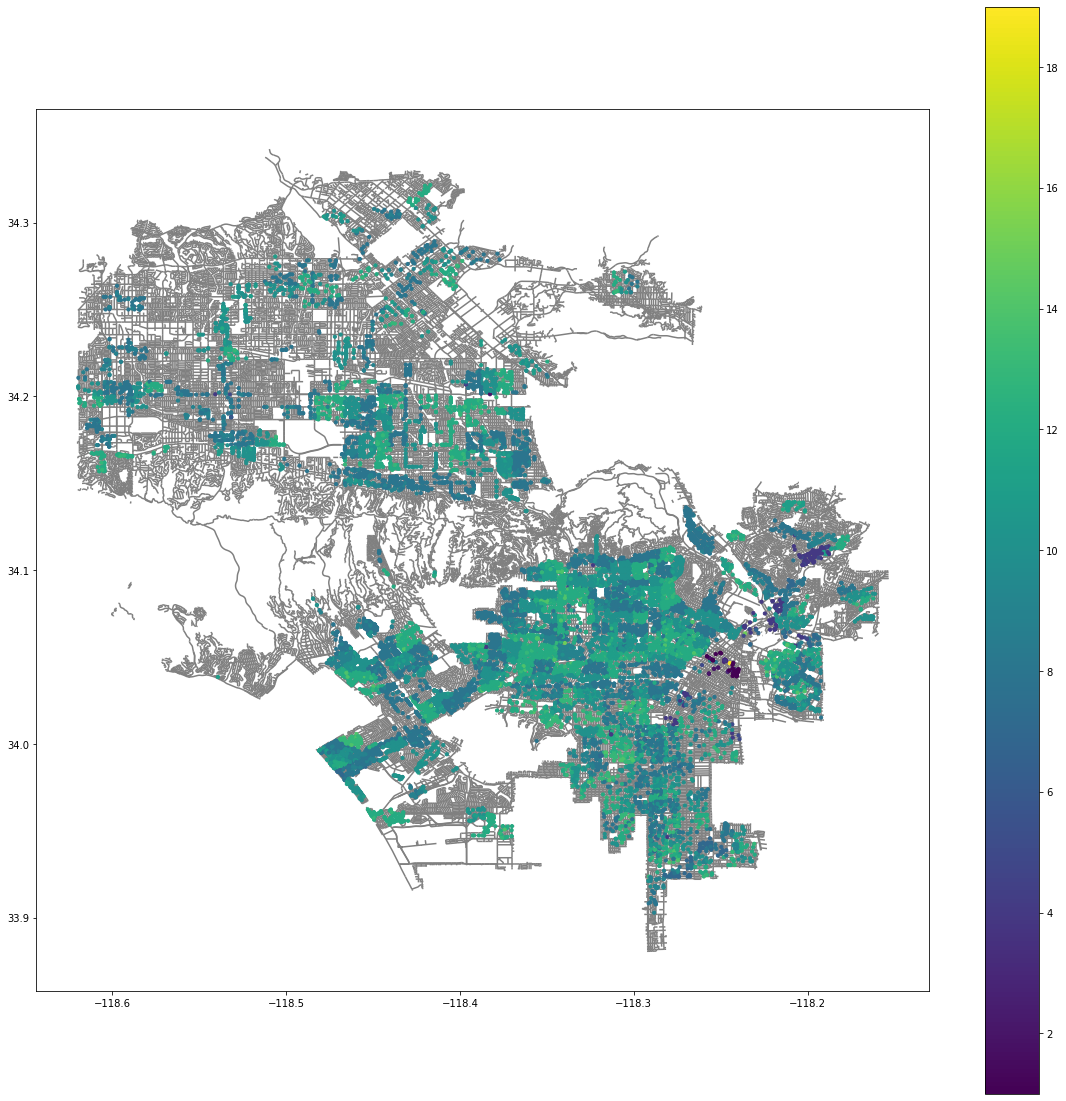

In [64]:
plot_points(34.18, -118.32, zoom=0.3, column='Hour', markersize=10)

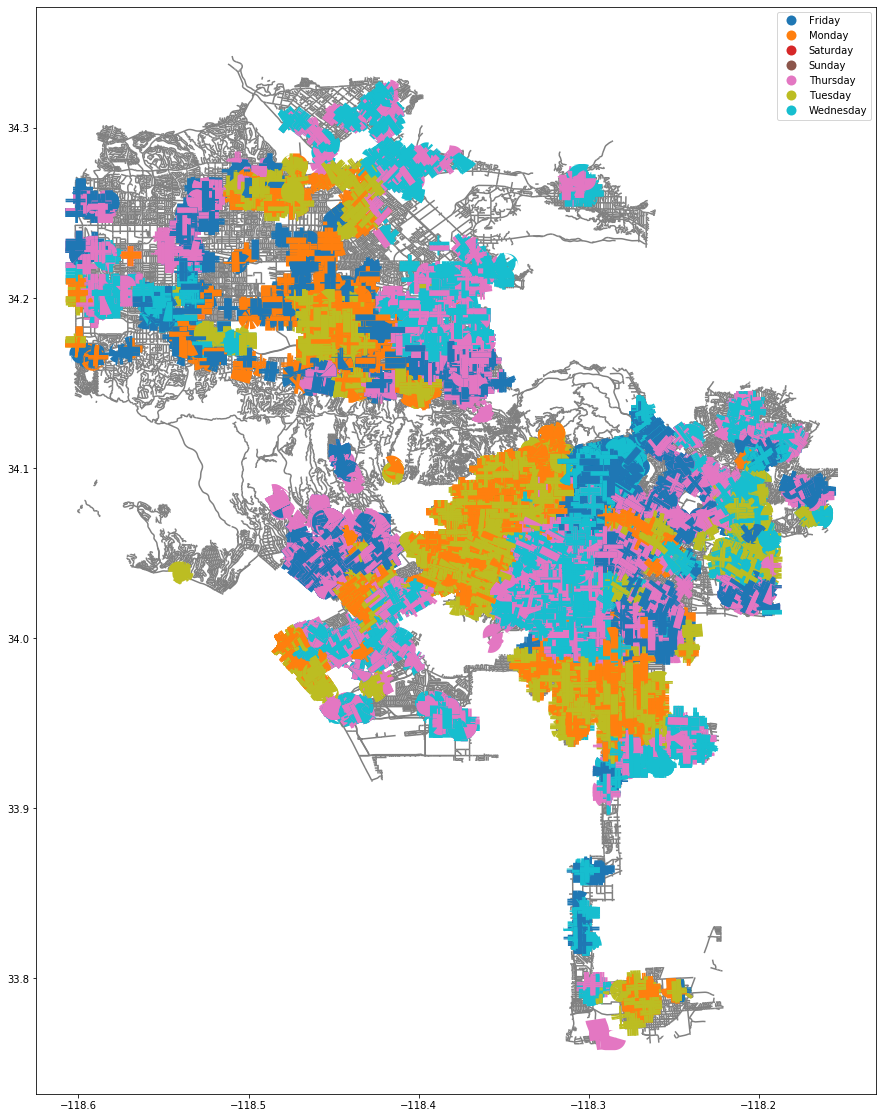

In [33]:
plot_streets(34.060988, -118.302358, zoom=0.3, linewidth=20)